## Primeira Clustering

In [1]:

#Para embeddings model

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text

#Bibliotecas para análise de Clusters
import umap
from hyperopt import fmin, tpe, hp, STATUS_OK, space_eval, Trials
from functools import partial
import hdbscan
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
from sklearn.preprocessing import StandardScaler

/Users/isabellaluna/Desktop/Pos_Tech/Tech-Challenges/tech_challenge_5/datathon-passos-magicos/.venv_tensor/lib/python3.11/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/Users/isabellaluna/Desktop/Pos_Tech/Tech-Challenges/tech_challenge_5/datathon-passos-magicos/.venv_tensor/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = 'data/BASE DE DADOS PEDE 2024 - DATATHON.xlsx'
df = pd.read_excel(path)

In [3]:
df.head(10)

,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,...,Inglês,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,...,6.0,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,...,9.7,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
2,RA-3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ametista,...,6.9,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...
3,RA-4,7,A,Aluno-4,2005,17,Menino,2017,Rede Decisão,Ametista,...,8.7,Não,Não,5.278,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
4,RA-5,7,A,Aluno-5,2005,17,Menina,2016,Rede Decisão,Ametista,...,5.7,Não,Não,7.389,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
5,RA-6,7,A,Aluno-6,2004,18,Menina,2021,Escola Pública,NaN,...,2.3,Sim,Não,7.222,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
6,RA-7,7,A,Aluno-7,2004,18,Menino,2017,Rede Decisão,Ametista,...,9.0,Não,Não,7.667,5.0,Fase 8 (Universitários),-1,Destaque: A sua boa entrega das lições de casa.,Destaque: As suas boas notas na Passos Mágicos.,Destaque: A sua boa integração aos Princípios ...
7,RA-8,7,A,Aluno-8,2002,20,Menina,2018,Escola Pública,Quartzo,...,2.9,Não,Não,6.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
8,RA-9,7,A,Aluno-9,2004,18,Menina,2019,Escola Pública,Ametista,...,8.7,Sim,Sim,9.500,5.0,Fase 8 (Universitários),-1,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...
9,RA-10,7,A,Aluno-10,2004,18,Menina,2021,Escola Pública,NaN,...,6.4,Não,Não,7.056,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...


In [4]:
#com busca de hiper para Umap:
def generate_clusters(message_embeddings,
                      n_neighbors,
                      n_components,
                      min_cluster_size,
                      min_samples = None,
                      random_state = None):
    """
    Returns HDBSCAN objects after first performing dimensionality reduction using UMAP

    Arguments:
        message_embeddings: embeddings to use
        n_neighbors: int, UMAP hyperparameter n_neighbors
        n_components: int, UMAP hyperparameter n_components
        min_cluster_size: int, HDBSCAN hyperparameter min_cluster_size
        min_samples: int, HDBSCAN hyperparameter min_samples
        random_state: int, random seed

    Returns:
        clusters: HDBSCAN object of clusters
    """

    umap_embeddings = (umap.UMAP(n_neighbors = n_neighbors,
                                n_components = n_components,
                                metric = 'cosine',
                                random_state=random_state)
                            .fit_transform(message_embeddings))

    clusters = hdbscan.HDBSCAN(min_cluster_size = min_cluster_size,
                               min_samples = min_samples,
                               metric='euclidean',
                               gen_min_span_tree=True,
                               cluster_selection_method='eom').fit(umap_embeddings)

    return clusters

def score_clusters(clusters, prob_threshold = 0.05):
    """
    Returns the label count and cost of a given clustering

    Arguments:
        clusters: HDBSCAN clustering object
        prob_threshold: float, probability threshold to use for deciding
                        what cluster labels are considered low confidence

    Returns:
        label_count: int, number of unique cluster labels, including noise
        cost: float, fraction of data points whose cluster assignment has
              a probability below cutoff threshold
    """

    cluster_labels = clusters.labels_
    label_count = len(np.unique(cluster_labels))
    total_num = len(clusters.labels_)
    cost = (np.count_nonzero(clusters.probabilities_ < prob_threshold)/total_num)

    return label_count, cost

def plot_clusters(embeddings, clusters, n_neighbors=15, min_dist=0.1):
    """
    Reduce dimensionality of best clusters and plot in 2D

    Arguments:
        embeddings: embeddings to use
        clusteres: HDBSCAN object of clusters
        n_neighbors: float, UMAP hyperparameter n_neighbors
        min_dist: float, UMAP hyperparameter min_dist for effective
                  minimum distance between embedded points

    """
    umap_data = umap.UMAP(n_neighbors=n_neighbors,
                          n_components=2,
                          min_dist = min_dist,
                          #metric='cosine',
                          random_state=42).fit_transform(embeddings)

    point_size = 100.0 / np.sqrt(embeddings.shape[0])

    result = pd.DataFrame(umap_data, columns=['x', 'y'])
    result['labels'] = clusters.labels_

    fig, ax = plt.subplots(figsize=(14, 8))
    outliers = result[result.labels == -1]
    clustered = result[result.labels != -1]
    plt.scatter(outliers.x, outliers.y, color = 'lightgrey', s=point_size)
    plt.scatter(clustered.x, clustered.y, c=clustered.labels, s=point_size, cmap='jet')
    plt.colorbar()
    plt.show()

def bayesian_search(embeddings, space, label_lower, label_upper, max_evals=100):
    """
    Perform bayesian search on hyperparameter space using hyperopt

    Arguments:
        embeddings: embeddings to use
        space: dict, contains keys for 'n_neighbors', 'n_components',
               'min_cluster_size', and 'random_state' and
               values that use built-in hyperopt functions to define
               search spaces for each
        label_lower: int, lower end of range of number of expected clusters
        label_upper: int, upper end of range of number of expected clusters
        max_evals: int, maximum number of parameter combinations to try

    Saves the following to instance variables:
        best_params: dict, contains keys for 'n_neighbors', 'n_components',
               'min_cluster_size', 'min_samples', and 'random_state' and
               values associated with lowest cost scenario tested
        best_clusters: HDBSCAN object associated with lowest cost scenario
                       tested
        trials: hyperopt trials object for search

        """

    trials = Trials()
    fmin_objective = partial(objective,
                             embeddings=embeddings,
                             label_lower=label_lower,
                             label_upper=label_upper)

    best = fmin(fmin_objective,
                space = space,
                algo=tpe.suggest,
                max_evals=max_evals,
                trials=trials)

    best_params = space_eval(space, best)
    print ('best:')
    print (best_params)
    print (f"label count: {trials.best_trial['result']['label_count']}")

    best_clusters = generate_clusters(embeddings,
                                      n_neighbors = best_params['n_neighbors'],
                                      n_components = best_params['n_components'],
                                      min_cluster_size = best_params['min_cluster_size'],
                                      min_samples = best_params['min_samples'],
                                      random_state = best_params['random_state'])

    return best_params, best_clusters, trials

def objective(params, embeddings, label_lower, label_upper):
    """
    Objective function for hyperopt to minimize

    Arguments:
        params: dict, contains keys for 'n_neighbors', 'n_components',
               'min_cluster_size', 'random_state' and
               their values to use for evaluation
        embeddings: embeddings to use
        label_lower: int, lower end of range of number of expected clusters
        label_upper: int, upper end of range of number of expected clusters

    Returns:
        loss: cost function result incorporating penalties for falling
              outside desired range for number of clusters
        label_count: int, number of unique cluster labels, including noise
        status: string, hypoeropt status

        """

    clusters = generate_clusters(embeddings,
                                 n_neighbors = params['n_neighbors'],
                                 n_components = params['n_components'],
                                 min_cluster_size = params['min_cluster_size'],
                                 random_state = params['random_state'])

    label_count, cost = score_clusters(clusters, prob_threshold = 0.05)

    #15% penalty on the cost function if outside the desired range of groups
    if (label_count < label_lower) | (label_count > label_upper):
        penalty = 0.15
    else:
        penalty = 0

    loss = cost + penalty

    return {'loss': loss, 'label_count': label_count, 'status': STATUS_OK}

In [5]:
# module_url = "https://tfhub.dev/google/universal-sentence-encoder-multilingual/3"
# model_use = hub.load(module_url)
# print(f"module {module_url} loaded")
    
# todas_transcricoes = list(df['texto_processado_embeddings'])
# embeddings_transcricoes = model_use(todas_transcricoes)
# print(len(embeddings_transcricoes))

features_cluster = ['IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 'Defas']
X = df[features_cluster].fillna(df[features_cluster].median())
X_scaled = StandardScaler().fit_transform(X)



#Definindo o espaço para busca de hiperparâmetros
hspace = {
    "n_neighbors": hp.choice('n_neighbors', range(3, 30)),
    "n_components": hp.choice('n_components', range(2, 8)),
    "min_cluster_size": hp.choice('min_cluster_size', range(10, 50)),
    "min_samples": hp.choice('min_samples', range(2, 12)),
    "random_state": 42
}

label_lower = 3
label_upper = 5
max_evals = 50

best_params_use, best_clusters_use, trials_use = bayesian_search(embeddings=X_scaled,
                                                                 space=hspace,
                                                                 label_lower=label_lower,
                                                                 label_upper=label_upper,
                                                                 max_evals=max_evals)

# Mostrando os melhores hiperparâmetros
print(best_params_use)

  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

/Users/isabellaluna/Desktop/Pos_Tech/Tech-Challenges/tech_challenge_5/datathon-passos-magicos/.venv_tensor/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



  2%|▏         | 1/50 [00:03<03:13,  3.95s/trial, best loss: 0.0]

/Users/isabellaluna/Desktop/Pos_Tech/Tech-Challenges/tech_challenge_5/datathon-passos-magicos/.venv_tensor/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



  4%|▍         | 2/50 [00:04<01:40,  2.09s/trial, best loss: 0.0]

...

 98%|█████████▊| 49/50 [00:48<00:00,  1.24trial/s, best loss: 0.0]

/Users/isabellaluna/Desktop/Pos_Tech/Tech-Challenges/tech_challenge_5/datathon-passos-magicos/.venv_tensor/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



100%|██████████| 50/50 [00:49<00:00,  1.01trial/s, best loss: 0.0]
best:
{'min_cluster_size': 13, 'min_samples': 3, 'n_components': 5, 'n_neighbors': 27, 'random_state': 42}
label count: 5


/Users/isabellaluna/Desktop/Pos_Tech/Tech-Challenges/tech_challenge_5/datathon-passos-magicos/.venv_tensor/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{'min_cluster_size': 13, 'min_samples': 3, 'n_components': 5, 'n_neighbors': 27, 'random_state': 42}


In [6]:
clusters = list(np.unique(best_clusters_use.labels_))
len(clusters)

5

In [7]:

def plot_clusters(embeddings, clusters, n_neighbors=15, min_dist=0.1):
    """
    Reduce dimensionality of best clusters and plot in 2D

    Arguments:
        embeddings: embeddings to use
        clusters: HDBSCAN object of clusters
        n_neighbors: float, UMAP hyperparameter n_neighbors
        min_dist: float, UMAP hyperparameter min_dist for effective
                  minimum distance between embedded points

    """
    umap_data = umap.UMAP(n_neighbors=n_neighbors,
                          n_components=2,
                          min_dist=min_dist,
                          #metric='cosine',
                          random_state=42).fit_transform(embeddings)

    point_size = 100.0 / np.sqrt(embeddings.shape[0])

    result = pd.DataFrame(umap_data, columns=['x', 'y'])
    result['labels'] = clusters.labels_

    fig, ax = plt.subplots(figsize=(14, 8))
    outliers = result[result.labels == -1]
    clustered = result[result.labels != -1]

    scatter_outliers = ax.scatter(outliers.x, outliers.y, color='lightgrey', s=point_size)
    scatter_clustered = ax.scatter(clustered.x, clustered.y, c=clustered.labels, s=point_size, cmap='jet')
    plt.colorbar(scatter_clustered, ax=ax)

    # Adicionando números de cluster aos pontos
    for i, txt in enumerate(clustered.labels):
        ax.annotate(txt, (clustered.x.iloc[i], clustered.y.iloc[i]), fontsize=8, ha='center', va='center')

    plt.show()

In [8]:
#Função para Gráfico Interativo

import plotly.express as px

def plot_clusters_interactive(embeddings, clusters, n_neighbors=15, min_dist=0.1):
    """
    Reduce dimensionality of best clusters and create an interactive 2D plot

    Arguments:
        embeddings: embeddings to use
        clusters: HDBSCAN object of clusters
        n_neighbors: float, UMAP hyperparameter n_neighbors
        min_dist: float, UMAP hyperparameter min_dist for effective
                  minimum distance between embedded points

    """
    umap_data = umap.UMAP(n_neighbors=n_neighbors,
                          n_components=2,
                          min_dist=min_dist,
                          # metric='cosine',
                          random_state=42).fit_transform(embeddings)

    result = pd.DataFrame(umap_data, columns=['x', 'y'])
    result['labels'] = clusters.labels_

    fig = px.scatter(result, x='x', y='y', color='labels', size_max=20,
                     title='Interactive Clustering Plot',
                     labels={'labels': 'Cluster'})

    fig.update_traces(marker=dict(size=10, opacity=0.7),
                      selector=dict(mode='markers'))
    
    fig.update_layout(width=500, height=500)

    fig.show()

/Users/isabellaluna/Desktop/Pos_Tech/Tech-Challenges/tech_challenge_5/datathon-passos-magicos/.venv_tensor/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


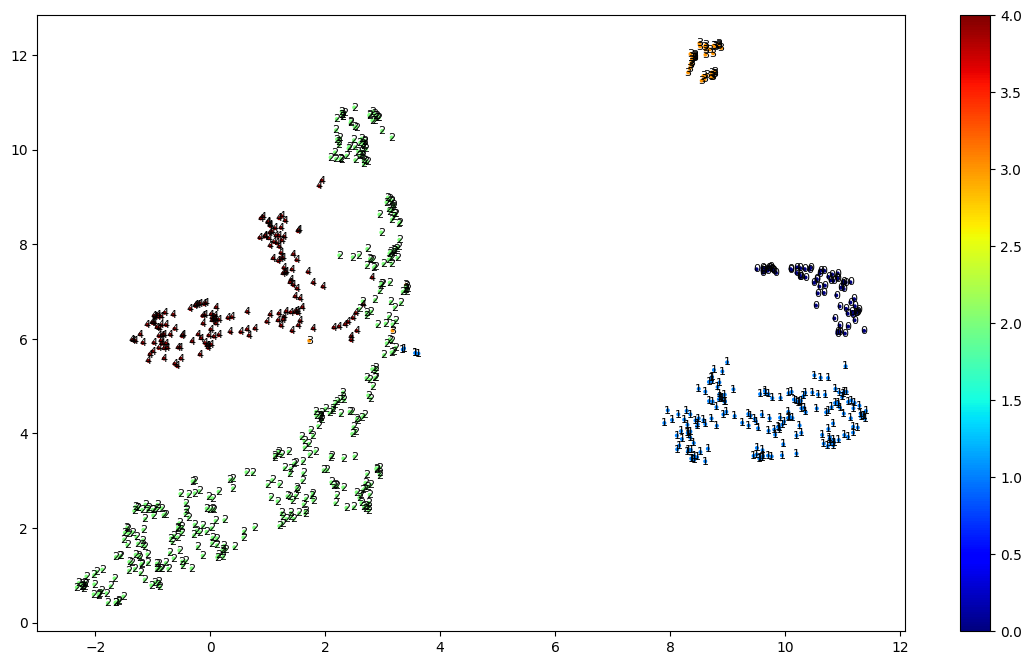

In [9]:
plot_clusters(X_scaled, best_clusters_use)

In [10]:
plot_clusters_interactive(X_scaled, best_clusters_use)

/Users/isabellaluna/Desktop/Pos_Tech/Tech-Challenges/tech_challenge_5/datathon-passos-magicos/.venv_tensor/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [11]:
df["grupo"] = best_clusters_use.labels_
#Salva um excel com os chamados e grupos
#df.to_excel(f"transcricoes_60-180_com_4_clusters_drilldown.xlsx")
df.head()

,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,...,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV,grupo
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,...,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,4
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,...,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,1
2,RA-3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ametista,...,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,3
3,RA-4,7,A,Aluno-4,2005,17,Menino,2017,Rede Decisão,Ametista,...,Não,Não,5.278,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,0
4,RA-5,7,A,Aluno-5,2005,17,Menina,2016,Rede Decisão,Ametista,...,Não,Não,7.389,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,0


In [12]:
df_1 = df[df["grupo"] == 1]
df_0 = df[df["grupo"] == 0]
print(df_1.shape)
print(df_0.shape)

(176, 43)
(72, 43)


In [13]:
#Filtrando os grupos distantes
df_filtrada1 = df[df["grupo"] != 1]
df_filtrada1 = df_filtrada1[df_filtrada1["grupo"] != 0]
df_filtrada1.shape

(612, 43)

# Segundo Agrupamento

In [14]:
# module_url = "https://tfhub.dev/google/universal-sentence-encoder-multilingual/3"
# model_use = hub.load(module_url)
# print(f"module {module_url} loaded")
    
# todas_transcricoes = list(df_filtrada1['texto_processado_embeddings'])
# embeddings_transcricoes = model_use(todas_transcricoes)
# print(len(embeddings_transcricoes))

features_cluster = ['IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 'Defas']
X = df[features_cluster].fillna(df[features_cluster].median())
X_scaled = StandardScaler().fit_transform(X)



#Definindo o espaço para busca de hiperparâmetros
hspace = {
    "n_neighbors": hp.choice('n_neighbors', range(3, 30)),
    "n_components": hp.choice('n_components', range(2, 8)),
    "min_cluster_size": hp.choice('min_cluster_size', range(10, 50)),
    "min_samples": hp.choice('min_samples', range(2, 12)),
    "random_state": 42
}

label_lower = 3
label_upper = 5
max_evals = 50

best_params_use, best_clusters_use, trials_use = bayesian_search(embeddings=X_scaled,
                                                                 space=hspace,
                                                                 label_lower=label_lower,
                                                                 label_upper=label_upper,
                                                                 max_evals=max_evals)

# Mostrando os melhores hiperparâmetros
print(best_params_use)

  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

/Users/isabellaluna/Desktop/Pos_Tech/Tech-Challenges/tech_challenge_5/datathon-passos-magicos/.venv_tensor/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



  2%|▏         | 1/50 [00:01<01:01,  1.26s/trial, best loss: 0.15]

/Users/isabellaluna/Desktop/Pos_Tech/Tech-Challenges/tech_challenge_5/datathon-passos-magicos/.venv_tensor/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



  4%|▍         | 2/50 [00:02<00:54,  1.13s/trial, best loss: 0.15]

...

 98%|█████████▊| 49/50 [00:44<00:00,  1.14trial/s, best loss: 0.0]

/Users/isabellaluna/Desktop/Pos_Tech/Tech-Challenges/tech_challenge_5/datathon-passos-magicos/.venv_tensor/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



100%|██████████| 50/50 [00:45<00:00,  1.10trial/s, best loss: 0.0]
best:
{'min_cluster_size': 16, 'min_samples': 4, 'n_components': 2, 'n_neighbors': 25, 'random_state': 42}
label count: 3


/Users/isabellaluna/Desktop/Pos_Tech/Tech-Challenges/tech_challenge_5/datathon-passos-magicos/.venv_tensor/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{'min_cluster_size': 16, 'min_samples': 4, 'n_components': 2, 'n_neighbors': 25, 'random_state': 42}


/Users/isabellaluna/Desktop/Pos_Tech/Tech-Challenges/tech_challenge_5/datathon-passos-magicos/.venv_tensor/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


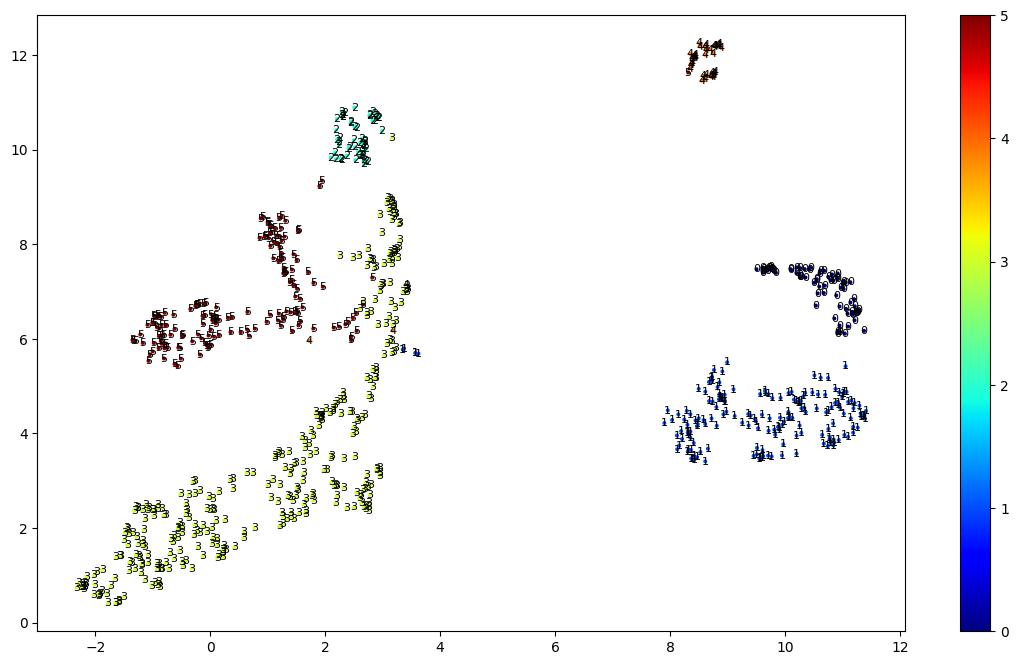

In [15]:
plot_clusters(X_scaled, best_clusters_use)

In [16]:
plot_clusters_interactive(X_scaled, best_clusters_use)

/Users/isabellaluna/Desktop/Pos_Tech/Tech-Challenges/tech_challenge_5/datathon-passos-magicos/.venv_tensor/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [17]:
df_filtrada1["grupo"] = best_clusters_use.labels_
#Salva um excel com os chamados e grupos
# df_filtrada1.to_excel(f"df_filtrado.xlsx")

ValueError: Length of values (860) does not match length of index (612)

In [ ]:
df_filtrada2 = df_filtrada1[df_filtrada1["grupo"] != 0]
print(df_filtrada2.shape)

## Terceiro Agrupamento

In [ ]:
# module_url = "https://tfhub.dev/google/universal-sentence-encoder-multilingual/3"
# model_use = hub.load(module_url)
# print(f"module {module_url} loaded")
    
# todas_transcricoes = list(df_filtrada2['texto_processado_embeddings'])
# embeddings_transcricoes = model_use(todas_transcricoes)
# print(len(embeddings_transcricoes))

features_cluster = ['IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 'Defas']
X = df[features_cluster].fillna(df[features_cluster].median())
X_scaled = StandardScaler().fit_transform(X)



#Definindo o espaço para busca de hiperparâmetros
hspace = {
    "n_neighbors": hp.choice('n_neighbors', range(3, 30)),
    "n_components": hp.choice('n_components', range(2, 8)),
    "min_cluster_size": hp.choice('min_cluster_size', range(10, 50)),
    "min_samples": hp.choice('min_samples', range(2, 12)),
    "random_state": 42
}

label_lower = 3
label_upper = 5
max_evals = 50

best_params_use, best_clusters_use, trials_use = bayesian_search(embeddings=X_scaled,
                                                                 space=hspace,
                                                                 label_lower=label_lower,
                                                                 label_upper=label_upper,
                                                                 max_evals=max_evals)

# Mostrando os melhores hiperparâmetros
print(best_params_use)

#Mostrando os melhores hiperparâmetros
print(best_params_use)

In [ ]:
clusters = list(np.unique(best_clusters_use.labels_))
len(clusters)

In [ ]:
plot_clusters(X_scaled, best_clusters_use)

In [ ]:
plot_clusters_interactive(X_scaled, best_clusters_use)

In [ ]:
df_filtrada2["grupo"] = best_clusters_use.labels_
df_filtrada2.head()